In [1]:
import json
import pandas as pd
from benchmark import evaluate_f1_between_manual_and_automatic, compare_manual_vs_automatic_scores_with_viz

In [2]:
manual_df = pd.read_csv("data/manual_curations_subset.csv")
manual_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165 entries, 0 to 164
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                165 non-null    int64  
 1   publication               165 non-null    object 
 2   pmid                      165 non-null    float64
 3   id                        163 non-null    object 
 4   gene                      165 non-null    object 
 5   inheritance               164 non-null    object 
 6   evidence_type             165 non-null    object 
 7   phenotype_quality         165 non-null    object 
 8   phenotyping_method_notes  164 non-null    object 
 9   genomic_variants          60 non-null     object 
 10  coding_variants           81 non-null     object 
 11  protein_variants          79 non-null     object 
 12  score_justification       165 non-null    object 
 13  score_range               162 non-null    object 
 14  initial_sc

In [3]:
manual_df.sample(3)

,Unnamed: 0,publication,pmid,id,gene,inheritance,evidence_type,phenotype_quality,phenotyping_method_notes,genomic_variants,coding_variants,protein_variants,score_justification,score_range,initial_score,final_score
39,61,Lennox AL et al. (2020): Pathogenic DDX3X Mut...,32135084.0,Patient ID: 2497-0,DDX3X,: de novo,Variant is de novomissense,Low Confidence in Phenotype,ASD: This is the largest cohort of patients ha...,g.33419613-33419615CAG>C,c.3963_3964del,p.P1321fs,Default score downgraded for phenotypic eviden...,0-1,0.0,0.25
139,229,"Carney RM, et al. (2003): Identification of Me...",12770674.0,Patient 2,MECP2,: de novo,Variant is de novo,High Confidence in Phenotype,ASD: The cases included in this study had a pr...,NaN,NaN,NaN,Default score downgraded for genotypic evidenc...,0-2.5,2.0,1.50
108,185,"Long S, et al. (2019): The Clinical and Geneti...",31139143.0,P027,MECP2,de novo,Variant is de novomissense,High Confidence in Phenotype,ASD: The study retrospectively recruited patie...,NaN,NaN,NaN,Default score applied.\nDe novo missense mutat...,0-1,0.0,0.50


In [4]:
with open("data/extracted_cases_NER.json") as f:
    eagle_ai_extractions = json.loads(f.read())


SCORE VERIFICATION SUMMARY
(Gene matching REQUIRED - only cases with matching genes are included)
(NOT SCORED cases are excluded entirely from comparison)
Total cases processed: 76
Publications with matches: 76
Cases with matches: 76
Exact score matches: 51
Overall matching rate: 100.0%
Exact match rate (of matched): 67.1%

Publication Match Types:
  - TITLE_AUTHOR_HIGH: 72
  - TITLE_HIGH: 4

Score Match Types:
  - EXACT_MATCH: 51
  - SIGNIFICANT_DIFFERENCE: 14
  - CLOSE_MATCH: 11

Score Differences:
  - Average absolute difference: 0.212
  - Median absolute difference: 0.000
  - Standard deviation: 0.399
  - Min/Max difference: 0.000 / 1.650

Case Matching Confidence:
  - Average confidence: 0.768
  - High confidence (≥0.8): 51
  - Medium confidence (≥0.5): 76
  - Low confidence (<0.5): 0


CREATING SCORE COMPARISON VISUALIZATIONS
Creating comprehensive score comparison visualizations...


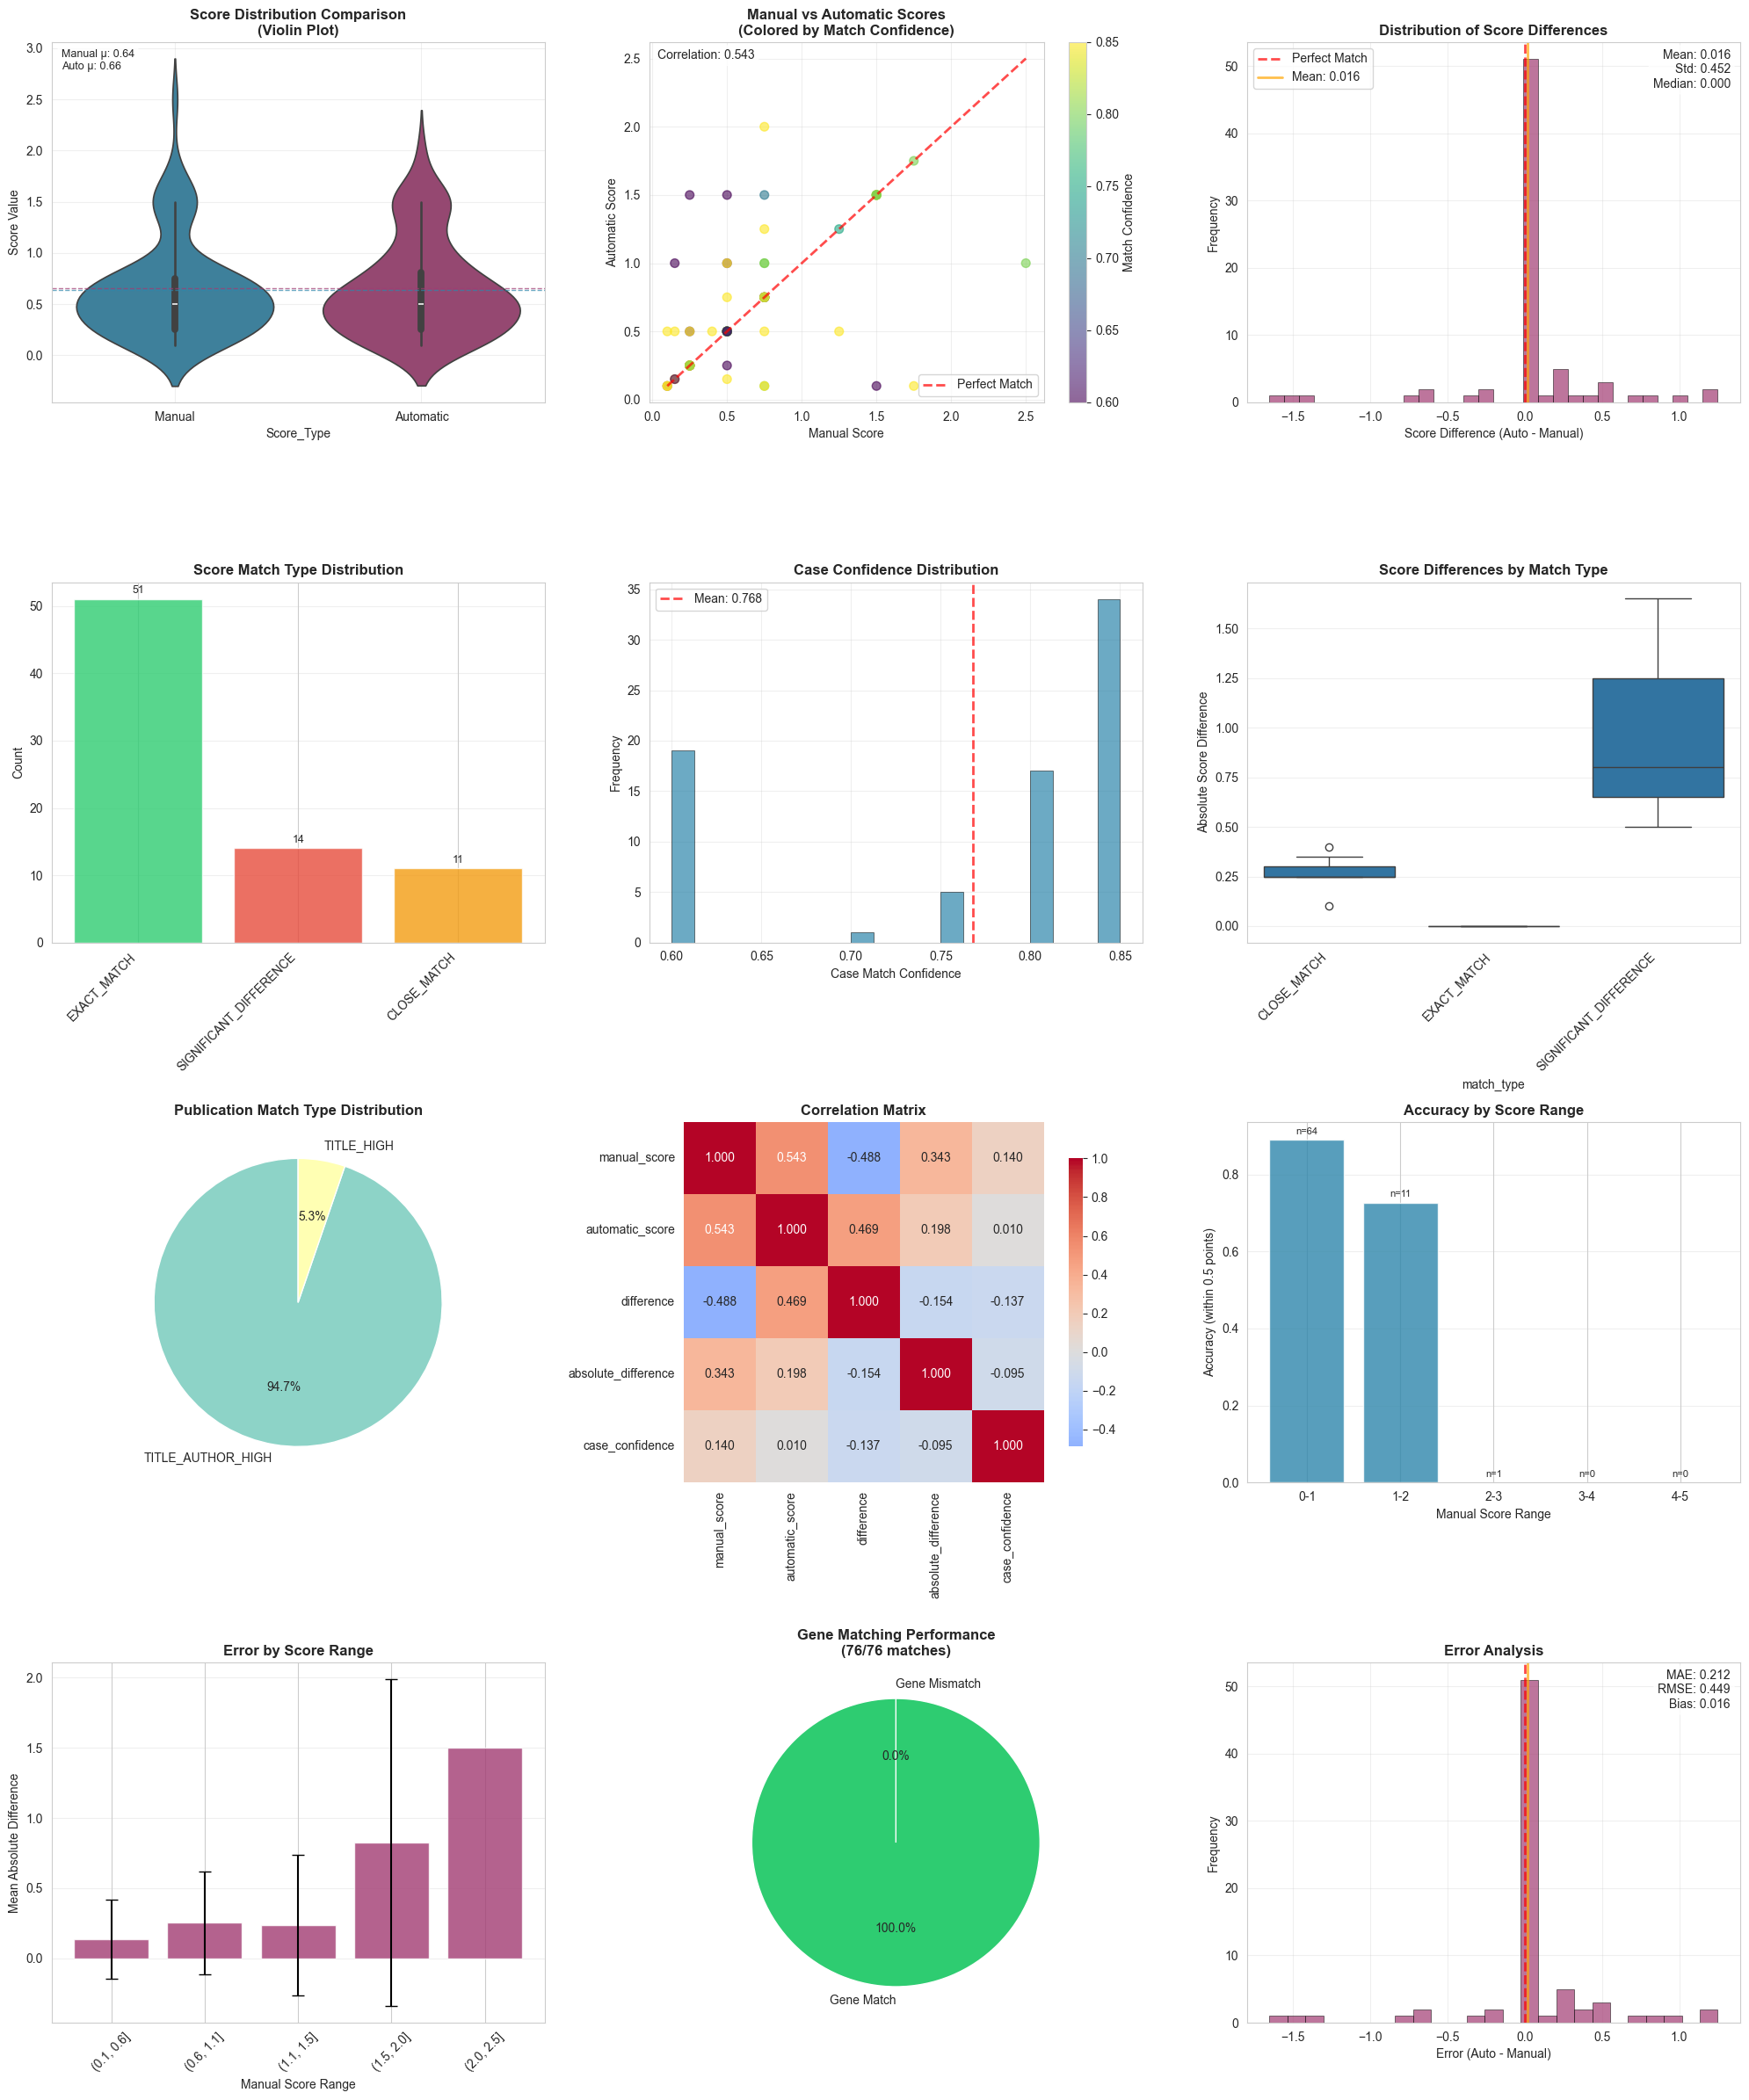

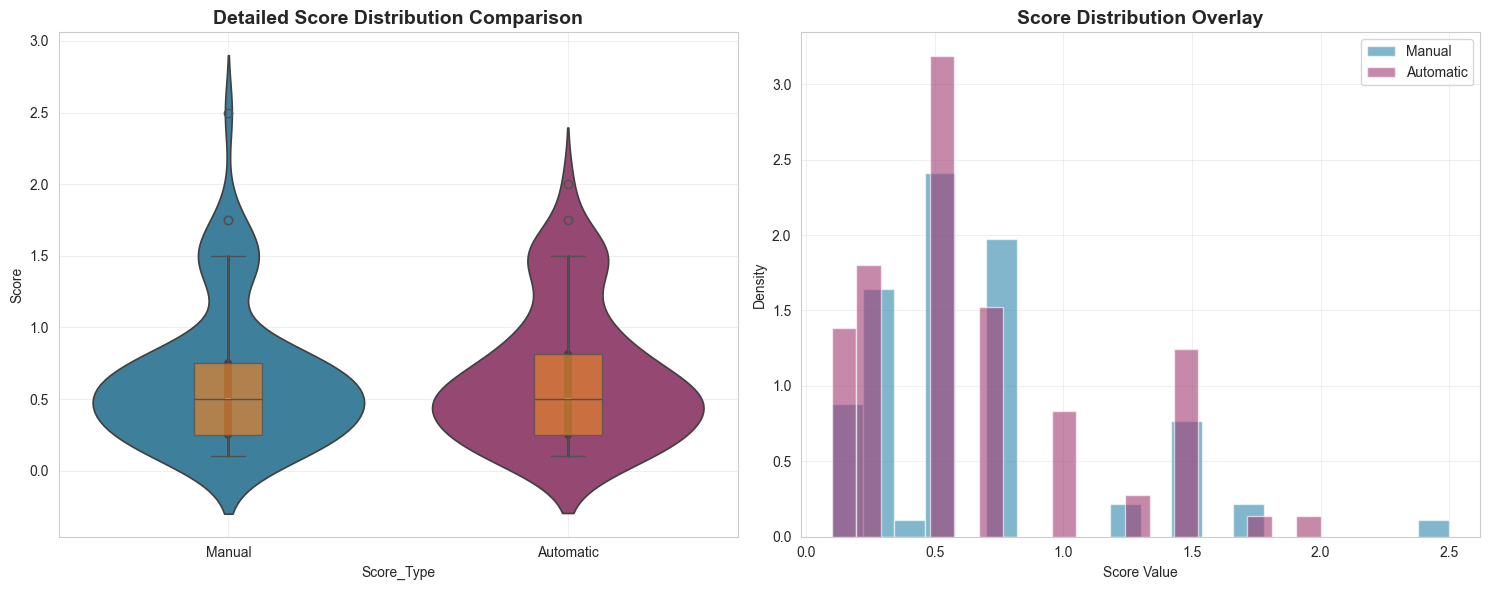

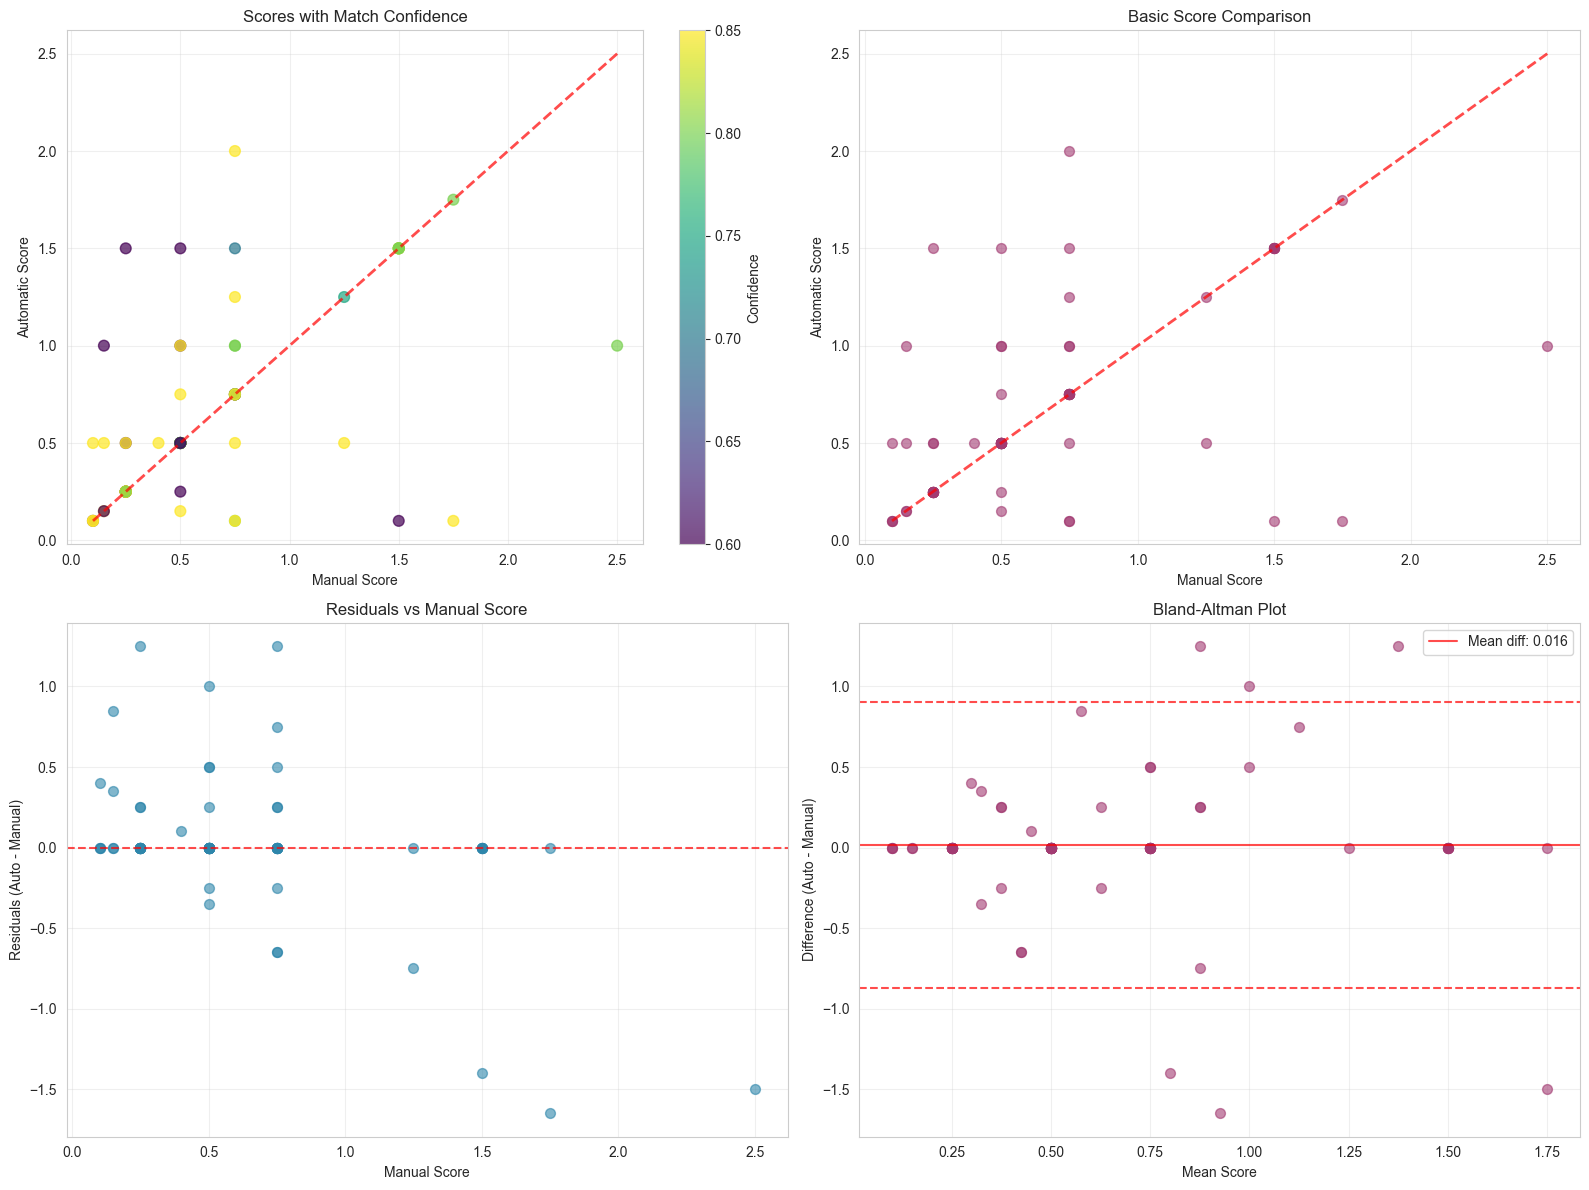

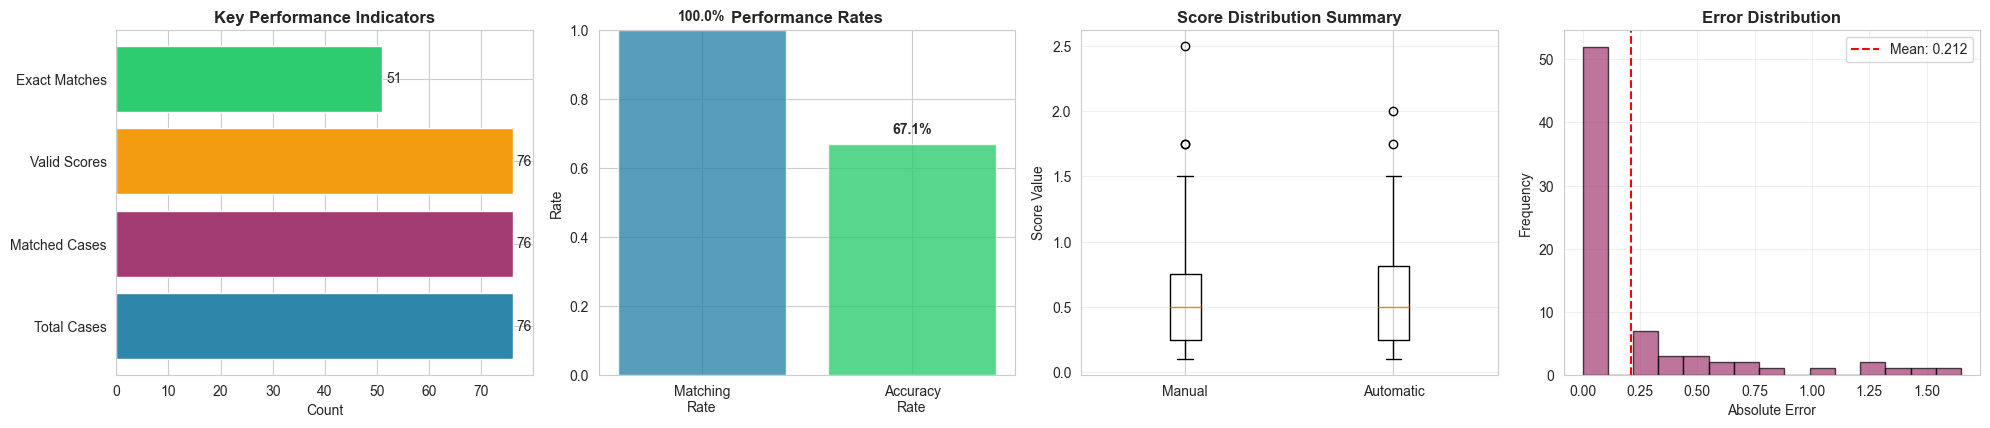


Visualization complete!


In [5]:
results = compare_manual_vs_automatic_scores_with_viz(manual_df=manual_df, auto_extractions=eagle_ai_extractions)

In [6]:
results

,publication_index,manual_dataset_publication,auto_extraction_dataset,case_index,manual_case_id,automatic_case_id,manual_gene,automatic_gene,manual_score,automatic_score,difference,absolute_difference,percentage_difference,scores_match,match_type,case_confidence,publication_match_type
0,0,Tran KT et al. (2020): Genetic landscape of au...,"Tran K, et al. - Genetic landscape of autism s...",0,ASD057,ASD057,DMD,DMD,0.10,0.50,0.40,0.40,400.000000,False,CLOSE_MATCH,0.85,TITLE_AUTHOR_HIGH
1,2,"Piton A, et al. (2011): Systematic resequencin...","Piton A, et al. - Systematic resequencing of X...",0,case_003,case_003,MECP2,MECP2,0.25,0.25,0.00,0.00,0.000000,True,EXACT_MATCH,0.85,TITLE_AUTHOR_HIGH
2,3,Valentino F et al. (2021): Exome Sequencing in...,"Valentino F, et al. - Exome Sequencing in 200 ...",0,Patient 11,Patient 11,DDX3X,DDX3X,0.25,0.25,0.00,0.00,0.000000,True,EXACT_MATCH,0.85,TITLE_AUTHOR_HIGH
3,4,"Zhang Q, et al. (2017): Familial cases and mal...","Zhang Q, et al. - Familial cases and male case...",0,"Family A, Proband II-1",Family A II:1,MECP2,MECP2,0.75,0.75,0.00,0.00,0.000000,True,EXACT_MATCH,0.80,TITLE_AUTHOR_HIGH
4,6,"Yamashita Y, et al. (2001): Mutation analysis ...","Yamashita Y, et al. - Mutation analysis of the...",0,Patient 1,Patient 1,MECP2,MECP2,0.75,0.75,0.00,0.00,0.000000,True,EXACT_MATCH,0.85,TITLE_AUTHOR_HIGH
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,72,Abdul-Rahman et al. (2006): The diagnostic uti...,"Abdul-Rahman OA, et al. - The diagnostic utili...",0,Patient 1,Patient 1,MECP2,MECP2,0.50,1.00,0.50,0.50,100.000000,False,SIGNIFICANT_DIFFERENCE,0.85,TITLE_AUTHOR_HIGH
72,73,"Saxena, A., et al (2006): Lost in translation...","Saxena A, et al. - Lost in translation: transl...",0,Patient 212. Single case reported in the study,Patient 212,MECP2,MECP2,0.75,1.00,0.25,0.25,33.333333,False,CLOSE_MATCH,0.80,TITLE_AUTHOR_HIGH
73,74,"Curie A, et al. (2017): Asperger syndrome and ...","Curie A, et al. - Asperger syndrome and early-...",0,Patient 1 (Dizygotic twin),Patient 1,MECP2,MECP2,0.25,0.25,0.00,0.00,0.000000,True,EXACT_MATCH,0.80,TITLE_AUTHOR_HIGH
74,75,"Noda S, et al. (2021): Duchenne Muscular Dystr...","Noda S, et al. - Duchenne Muscular Dystrophy S...",0,Case report,case_001,DMD,DMD,0.50,0.50,0.00,0.00,0.000000,True,EXACT_MATCH,0.60,TITLE_AUTHOR_HIGH


In [7]:
f1_scores = evaluate_f1_between_manual_and_automatic(
    manual_df=manual_df,
    auto_extractions=eagle_ai_extractions
)


F1 EVALUATION REPORT

Cases (manual vs automatic):
  - Precision: 0.927
  - Recall:    0.461
  - F1:        0.615  (TP=76, FP=6, FN=89)

Phenotype quality (High/Medium/Low):
  - Micro P: 0.676, R: 0.632, F1: 0.653
  - Macro F1: 0.623
    - High   P: 0.639, R: 0.793, F1: 0.708
    - Medium P: 0.538, R: 0.438, F1: 0.483
    - Low    P: 0.818, R: 0.581, F1: 0.679
